<a href="https://colab.research.google.com/github/iconrealestate77/Analyzeabtest/blob/main/analyze_ab_test_results_project_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyze A/B Test Results

This project will ensure you have mastered the subjects covered in the Hypothesis Testing lessons.  The hope is to have this project be as comprehensive of these topics as possible.  Good luck!

Corresponding with this notebook is a slide deck where you will need to update all the portions in red.  Completing the notebook will provide all the results needed for the slides.  **Correctly completing the slides is a required part of the project.**

## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Probability](#probability)
- [Part III - Experimentation](#experimentation)


<a id='intro'></a>
### Introduction

A/B tests are very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of an A/B test run by an e-commerce website.  Your goal is to work through this notebook to help the company understand if they should implement the new page, keep the old page, or perhaps run the experiment longer to make their decision.

**As you work through this notebook, follow along in the classroom and answer the corresponding quiz questions associated with each question.** The labels for each classroom concept are provided for each question.  This will assure you are on the right track as you work through the project, and you can feel more confident in your final submission meeting the criteria.  As a final check, assure you meet all the criteria on the rubric.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(0)
#Ensure to add the random.seed(0) to every cell
#that includes np.random to ensure consistency

In [6]:
from google.colab import files
uploaded = files.upload()


Saving ab_data.csv to ab_data.csv


For all questions in `Part I` notice links to [pandas documentation](https://pandas.pydata.org/) are provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`a)` Now, read in the `ab_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**.

In [7]:
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful pandas link - `Dataframe.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [8]:
df.shape[0]


69889

`c)` The proportion of users converted.  [Helpful  Pandas Link - `Dataframe.mean`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html)

In [9]:
df['converted'].mean()


np.float64(0.13047832992316388)

`d)` Do any of the rows have missing values? [Helpful Pandas Link - `Dataframe.isnull`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [Helpful Pandas Link- `Dataframe.sum`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

In [10]:
df.isnull().sum()


,0
country,0
group,0
converted,0


`e)` How many customers are from each country? Build a bar chart to show the count of visits from each country.

In [11]:
# number of visitors from each country - pull the necessary code from the next cell to provide just the counts
df['country'].value_counts()


,count
country,
US,48850
UK,17551
CA,3488


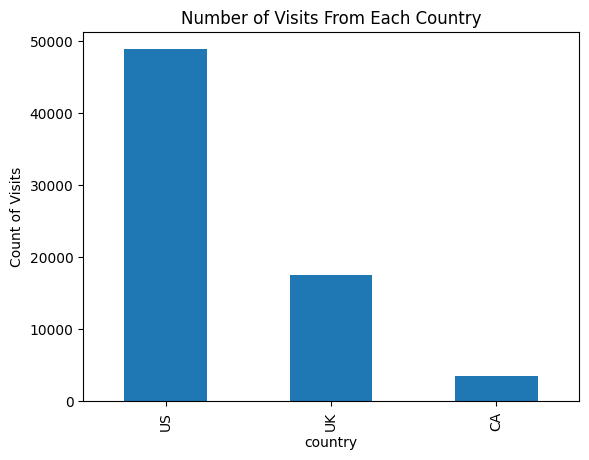

In [12]:
# bar chart of results - this part is done for you
df['country'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Country');
plt.ylabel('Count of Visits');
plt.show();

`f)` Recognize that all of your columns are of a **categorical data type** with the exception of one.  Which column is not **categorical**? [Helpful Pandas Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69889 entries, 0 to 69888
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    69889 non-null  object
 1   group      69889 non-null  object
 2   converted  69889 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


`g)` What are the possible values of the `converted` column?  Does it make sense that these values are the only possible values? Why or why not?

**Here you can use one of the functions you used in an earlier question**.

In [14]:
df['converted'].unique()


array([0, 1])

<a id='probability'></a>
#### Part II - Probability

Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `converting`.

`a)` What is the probability of an individual converting regardless of the page they receive or the country they are from? Simply, what is the chance of conversion in the dataset?

In [15]:
df['converted'].mean()


np.float64(0.13047832992316388)

`b)` Given that an individual was in the `control` group, what is the probability they converted? **This question is completed for you**

In [16]:
df.query('group == "control"')['converted'].mean()

np.float64(0.1052540515600669)

`c)` Given that an individual was in the `treatment` group, what is the probability they converted?

In [17]:
df.query('group == "treatment"')['converted'].mean()


np.float64(0.15532078043793132)

`d)` Do you see evidence that the treatment is related to higher `converted` rates?

The control group converted at approximately 10.5%, while the treatment group converted at approximately 15.5% — about 5 percentage points higher. This suggests the treatment page may be associated with a higher conversion rate than the control page. However, this is just a raw comparison of averages; it doesn’t yet tell us whether this difference is statistically significant or could simply be due to random chance. We’ll test that formally in Part III using hypothesis testing.

`e)` What is the probability that an individual was in the `treatment`?

In [18]:
(df['group'] == 'treatment').mean()


np.float64(0.5038131894861853)

`f)` What is the probability that an individual was from Canada `CA`?

In [19]:
(df['country'] == 'CA').mean()


np.float64(0.04990771079855199)

`g)` Given that an individual was in the `US`, what was the probability that they `converted`? **This question is completed for you**

$P(\text{converted} == 1|\text{country} ==\text{"US"})$



In [20]:
df.query('country == "US"')['converted'].mean()

np.float64(0.13277379733879222)

`h)` Given that an individual was in the `UK`, what was the probability that they `converted`?

$P(\text{converted} == 1|\text{country} ==\text{"UK"})$

In [21]:
df.query('country == "UK"')['converted'].mean()


np.float64(0.12512107572218106)

`i)` Do you see evidence that the `converted` rate might differ from one country to the next?

In [22]:
df.groupby('country')['converted'].mean()


,converted
country,
CA,0.125287
UK,0.125121
US,0.132774


Looking at conversion rates by country — CA: 12.5%, UK: 12.5%, US: 13.3% — the rates are very close across all three countries, within about 1 percentage point of each other. This suggests country alone doesn’t appear to have a strong relationship with conversion rate; visitors convert at roughly similar rates regardless of where they’re from.

`j)` Consider the table below, fill in the conversion rates below to look at how conversion by country and treatment group vary.  The `US` column is done for you, and two methods for calculating the probabilities are shown - **COMPLETE THE REST OF THE TABLE**.  Does it appear that there could be an interaction between how country and treatment impact conversion?

These two values that are filled in can be written as:

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"control"})) = 10.7\%$

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"treatment"})) = 15.8\%$

|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       |  %          |  %          |
| Treatment   | 15.8%       |  %          |  %          |

In [23]:
df.query('country == "UK"').groupby('group')['converted'].mean()


,converted
group,
control,0.101649
treatment,0.148698


In [24]:
df.query('country == "CA"').groupby('group')['converted'].mean()


,converted
group,
control,0.094474
treatment,0.154017


|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       | 10.2%       | 9.4%        |
| Treatment   | 15.8%       | 14.9%       | 15.4%       |


In [25]:
df.query('country == "UK"').groupby('group')['converted'].mean()


,converted
group,
control,0.101649
treatment,0.148698


In [26]:
df.query('country == "CA"').groupby('group')['converted'].mean()


,converted
group,
control,0.094474
treatment,0.154017


Across all three countries, the treatment group consistently converts at a higher rate than the control group, with the gap ranging from about 4.7 to 6 percentage points. This pattern is fairly consistent, so there isn’t strong evidence of an interaction effect — the treatment effect doesn’t appear to meaningfully change direction or size depending on the country.

<a id='experimentation'></a>
### Part III - Experimentation

Consider you need to make the decision just based on all the data provided.  If you want to assume that the control page is better unless the treatment page proves to be definitely better at a Type I error rate of 5%, you state your null and alternative hypotheses in terms of **$p_{control}$** and **$p_{treatment}$** as:  

$H_{0}: p_{control} >= p_{treatment}$

$H_{1}: p_{control} < p_{treatment}$

Which is equivalent to:

$H_{0}: p_{treatment} - p_{control} <= 0$

$H_{1}: p_{treatment} - p_{control} > 0$


Where  
* **$p_{control}$** is the `converted` rate for the control page
* **$p_{treatment}$** `converted` rate for the treatment page

**Note for this experiment we are not looking at differences associated with country.**

Assume under the null hypothesis, $p_{treatment}$ and $p_{control}$ both have "true" success rates equal to the **converted** success rate regardless of page - that is $p_{treatment}$ and $p_{control}$ are equal. Furthermore, assume they are equal to the **converted** rate in `df` regardless of the page. **These are set in the first cell below.**<br><br>

* Use a sample size for each page equal to the ones in `df`. **These are also set below.**  <br><br>

* Perform the sampling distribution for the difference in `converted` between the two pages over 500 iterations of calculating an estimate from the null.  <br><br>

* Use the cells below to provide the necessary parts of this simulation.  

If this doesn't make complete sense right now, don't worry - you are going to work through the problems below to complete this problem.  You can use **Quiz 4** in the classroom to make sure you are on the right track.<br><br>

`a)` The **convert rate** for $p_{treatment}$ under the null.  The **convert rate** for $p_{control}$ under the null. The sample size for the `control` and the sample size for the `treatment` are from the original dataset. **All of these values are set below, and set the stage for the simulations you will run for the rest of this section.**

In [27]:
p_control_treatment_null  = df['converted'].mean()
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]

`b)` Use the results from part `a)` to simulate `n_treatment` transactions with a convert rate of `p_treatment_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **treatment_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be the same):

`[0, 0, 1, 1, 0, ....]`

In [28]:
treatment_converted = np.random.choice([0, 1], size=n_treatment, p=[1-p_control_treatment_null, p_control_treatment_null])


`c)` Use the results from part `a)` to simulate `n_control` transactions with a convert rate of `p_control_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **control_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be exactly the same):

`[0, 0, 1, 1, 0, ....]`

In [33]:
control_converted = np.random.choice([0, 1], size=n_control, p=[1-p_control_treatment_null, p_control_treatment_null])


`d)` Find the estimate for $p_{treatment}$ - $p_{control}$ under the null using the simulated values from part `(b)` and `(c)`.

In [34]:
p_treatment_null = np.mean(treatment_converted)
p_control_null = np.mean(control_converted)
p_treatment_null - p_control_null


np.float64(-0.0009702902048186468)

`e)` Simulate 500 $p_{treatment}$ - $p_{control}$ values using this same process as `b)`- `d)` above.  Store all 500 values in an numpy array called **p_diffs**.  This array should look similar to the below **(the values will not match AND this will likely take a bit of time to run)**:

`[0.001, -0.003, 0.002, ...]`

In [35]:
p_diffs = []
for _ in range(500):
    treatment_sim = np.random.choice([0, 1], size=n_treatment, p=[1-p_control_treatment_null, p_control_treatment_null])
    control_sim = np.random.choice([0, 1], size=n_control, p=[1-p_control_treatment_null, p_control_treatment_null])
    p_treatment_null = np.mean(treatment_sim)
    p_control_null = np.mean(control_sim)
    p_diffs.append(p_treatment_null - p_control_null)

p_diffs = np.array(p_diffs)


`f)` Plot a histogram of the **p_diffs**.  Does this plot look like what you expected?  Use the matching problem in the classroom to assure you fully understand what was computed here.

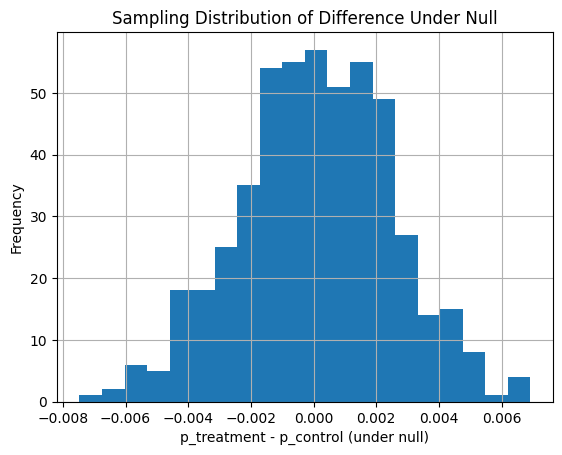

In [36]:
p_diffs = pd.Series(p_diffs)
p_diffs.hist(bins=20)
plt.xlabel('p_treatment - p_control (under null)')
plt.ylabel('Frequency')
plt.title('Sampling Distribution of Difference Under Null')
plt.show()


`g)` What proportion of the **p_diffs** are greater than the difference observed between `treatment` and `control` in `df`?

In [37]:
obs_diff = df.query('group == "treatment"')['converted'].mean() - df.query('group == "control"')['converted'].mean()
(p_diffs > obs_diff).mean()


np.float64(0.0)

`h)` In words, explain what you just computed in part `g)`  What is this value called in scientific studies?  What does this value mean in terms of whether or not there is a difference between the new and old pages using our Type I error rate of 0.05?

The value computed in part g) is the p-value. It represents the probability of observing a difference between treatment and control as large as (or larger than) the one we actually saw, if the null hypothesis were true (i.e., if there were truly no difference between the pages).
In this case, the p-value is 0.0 — none of the 500 simulated differences under the null came close to matching the actual observed difference of about 5 percentage points. Since this p-value is far below our significance threshold of 0.05, we reject the null hypothesis. This provides strong statistical evidence that the treatment page has a higher conversion rate than the control page, and the difference we observed is highly unlikely to be due to random chance alone.

<a id='finalcheck'></a>
## Final Check!

Congratulations!  You have reached the end of the A/B Test Results project!  You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your notebook to make sure that it satisfies all the specifications mentioned in the rubric. You should also probably remove all of the "Hints" and "Tips" like this one so that the presentation is as polished as possible.


<a id='submission'></a>
## Submission

Please follow the directions in the classroom to submit this notebook, as well as your completed slides.